# Instalación de librerias y carga del dataset

In [ ]:
!pip -q install cartopy mintpy
%matplotlib inline
!smallbaselineApp.py



import os
import numpy as np
import matplotlib.pyplot as plt
import shutil
import glob, os
import h5py
import matplotlib.pyplot as plt


from PIL import Image
from IPython.display import IFrame, Image, display
from cartopy import crs as ccrs
from mintpy.utils import readfile, utils as ut, plot as pp
from mintpy.cli import view, tsview, plot_network, plot_transection
from mintpy.view import prep_slice, plot_slice

# Cargando la base de datos para procesar con MintPy-Preparar visualizaciones

## Miami InSAR Time-series software in Python : Es un paquete diseñado para analizar series temporales en imágenes InSAR (Interferometric Synthetic Aperture Radar)

# Se puede aplicar a diferentes tareas :


*   Subsidencia
*   Deformaciones del terreno
*   Fallas tectónicas
*   Deslizamientos




In [ ]:
plt.rcParams.update({'font.size': 12})

# Función actualizar configs de MintPy
def write_config_file(out_file, CONFIG_TXT, mode='a'):
    if not os.path.isfile(out_file) or mode == 'w':
        with open(out_file, "w") as fid:
            fid.write(CONFIG_TXT)
        print(f'write configuration to file: {out_file}')
    else:
        with open(out_file, "a") as fid:
            fid.write("\n" + CONFIG_TXT)
        print(f'add the following to file: \n{CONFIG_TXT}')


# Directorio de la base de datos
base_dir = "/content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42"
work_dir = os.path.join(base_dir, "mintpy")
inputs_dir = os.path.join(work_dir, "inputs")


assert os.path.isdir(work_dir), f"No existe work_dir: {work_dir}"
assert os.path.isdir(inputs_dir), f"No existe inputs_dir: {inputs_dir}"

required = ["ifgramStack.h5", "geometryGeo.h5"]
missing = [f for f in required if not os.path.isfile(os.path.join(inputs_dir, f))]
assert not missing, f"Faltan archivos en {inputs_dir}: {missing}"

os.chdir(work_dir)
print("Go to work directory:", work_dir)
print("Inputs OK:", os.listdir("inputs"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 995.8/995.8 kB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 138.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.8/484.8 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 54.4 MB/s eta 0:00:00
usage: smallbaselineApp.py [-h] [--dir WORKDIR] [-g] [-H] [-v] [--plot]
                           [--start STEP] [--end STEP] [--dostep STEP]
                           [customTemplateFile]
example:
  smallbasel

# Procesamiento SBAS

## **SBAS : Small Baseline Subset**, es una técnica InSAR de series temporales, que permite seleccionar interferogramas con pequeñas baselines para estimar series temporales de deformación del terreno.

In [ ]:
!smallbaselineApp.py -g

--------------------------------------------------
Go to work directory: /content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42/mintpy
read default template file: /content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42/mintpy/smallbaselineApp.cfg
Go back to directory: /content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42/mintpy

################################################
   Normal end of smallbaselineApp processing!
################################################
Time used: 00 mins 0.4 secs



# Verificación de los archivos, posterior al proceso SBAS

# Los archivos están en formato .h5 = HDF5 (Hierarchical data format versión 5), es un contenedor estructurado, que guarda matrices multidimensionales

In [ ]:
print("H5 generados:", sorted([os.path.basename(f) for f in glob.glob("*.h5")]))
print("En inputs:", os.listdir("inputs")[:20])

H5 generados: ['avgPhaseVelocity.h5', 'avgSpatialCoh.h5', 'maskConnComp.h5', 'numInvIfgram.h5', 'numTriNonzeroIntAmbiguity.h5', 'temporalCoherence.h5', 'timeseries.h5', 'waterMask.h5']
En inputs: ['geometryGeo.h5', 'smallbaselineApp.cfg', 'ifgramStack.h5']


# Modo lectura de los archivos HDF5

## Datos que se encuentran dentro del HDF5  

In [ ]:
f = "inputs/ifgramStack.h5"
try:
    with h5py.File(f, "r") as h5:
        print("bre OK. Keys top:", list(h5.keys())[:10])
except Exception as e:
    print("No abre:", repr(e))

bre OK. Keys top: ['bperp', 'coherence', 'connectComponent', 'date', 'dropIfgram', 'unwrapPhase']


# Ejecución  de la aplicación Small Baseline App

# Preparación de los datos

*  Lee el archivo ifgramStack.h5
*  Lee geometryGeo.h5

Selección de interferogramas

*   Baseline temporal
*   Bseline perpendicular
*   Coherencia




**Inversión SBAS**


# Devuelve las fases desenrolladas utilizando la ecuación d = Gm

Donde G es la matriz de la red de interferogramas y
m es la deformación acumulada en cada fecha

Esto genera un nuevo archivo .h5 con las series de tiempo y el mapa de velocidad promedio (mm/año)



In [ ]:
!smallbaselineApp.py smallbaselineApp.cfg


___________________________________________________________

  /##      /## /##             /##     /#######
 | ###    /###|__/            | ##    | ##__  ##
 | ####  /#### /## /#######  /######  | ##  \ ## /##   /##
 | ## ##/## ##| ##| ##__  ##|_  ##_/  | #######/| ##  | ##
 | ##  ###| ##| ##| ##  \ ##  | ##    | ##____/ | ##  | ##
 | ##\  # | ##| ##| ##  | ##  | ## /##| ##      | ##  | ##
 | ## \/  | ##| ##| ##  | ##  |  ####/| ##      |  #######
 |__/     |__/|__/|__/  |__/   \___/  |__/       \____  ##
                                                 /##  | ##
                                                |  ######/
   Miami InSAR Time-series software in Python    \______/
          MintPy 1.6.2, 2025-07-07
___________________________________________________________

--RUN-at-2026-02-24 14:30:46.822540--
Current directory: /content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42/mintpy
Run routine processing with smallbaselineApp.py on steps: ['load_data', 'modify_network', 'refere

# Calculo de la velocidad

In [ ]:
%cd /content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42/mintpy
!timeseries2velocity.py timeseries.h5 -o velocity.h5
!ls -lh velocity.h5

/content
open timeseries file: timeseries.h5
--------------------------------------------------
dates from input file: 189
['20150301', '20150325', '20150418', '20150512', '20150605', '20150629', '20150723', '20150816', '20150909', '20151003', '20151027', '20151120', '20151214', '20160107', '20160131', '20160224', '20160319', '20160412', '20160506', '20160530', '20160810', '20160903', '20160927', '20161021', '20161114', '20161208', '20170101', '20170113', '20170119', '20170125', '20170218', '20170302', '20170326', '20170407', '20170419', '20170501', '20170513', '20170606', '20170618', '20170630', '20170712', '20170724', '20170805', '20170817', '20170910', '20171004', '20171016', '20171028', '20171109', '20171121', '20171203', '20171215', '20171227', '20180108', '20180120', '20180201', '20180213', '20180225', '20180321', '20180402', '20180414', '20180426', '20180508', '20180520', '20180601', '20180613', '20180625', '20180707', '20180719', '20180731', '20180812', '20180824', '20180905', 

# Inspección de estructura interna de los archivos HDF5

In [ ]:
!info.py inputs/geometryGeo.h5
!info.py inputs/ifgramStack.h5
!info.py inputs/ifgramStack.h5 --date --num --compact

******************** Basic File Info ************************
file name: /content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42/mintpy/inputs/geometryGeo.h5
file type: geometry
coordinates : GEO

******************** HDF5 File Structure ********************
Attributes in / level:
  ALOOKS                   7
  ANTENNA_SIDE             -1
  CENTER_LINE_UTC          50850.0
  EARTH_RADIUS             6337286.638938101
  FILE_LENGTH              1021
  FILE_TYPE                geometry
  HEADING                  -168
  HEIGHT                   693000.0
  LAT_REF1                 38.1012347595
  LAT_REF2                 38.1012347595
  LAT_REF3                 37.250401766500005
  LAT_REF4                 37.250401766500005
  LENGTH                   1021
  LON_REF1                 -121.75036796650001
  LON_REF2                 -122.6012009595
  LON_REF3                 -121.75036796650001
  LON_REF4                 -122.6012009595
  NCORRLOOKS               61.29302259485575
  NUMBER_OF_PA

# Visualización de la red interferométrica SBAS

In [ ]:
!plot_network.py inputs/ifgramStack.h5 -t smallbaselineApp.cfg --figsize 12 4 -d coherence -v 0.2 1.0

read options from template file: smallbaselineApp.cfg
read temporal/spatial baseline info from file: inputs/ifgramStack.h5
open ifgramStack file: ifgramStack.h5
['coherenceSpatialAvg.txt'] exists and is newer than ['waterMask.h5'] --> skip.
coherenceSpatialAvg.txt already exists, read it directly
/usr/local/lib/python3.12/dist-packages/mintpy/utils/utils1.py:198: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  txtContent = np.loadtxt(fname, dtype=bytes).astype(str)
number of acquisitions: 189
number of interferograms: 961
shift all perp baseline

In [ ]:
!view.py timeseries.h5 -v -5 5
!view.py temporalCoherence.h5
!view.py velocity.h5 velocity -u mm -v -1 1

run view.py in MintPy version 1.6.2, date 2025-07-07
input file is timeseries file: /content/drive/MyDrive/Colab/Geotermia/SanFranSenDT42/mintpy/timeseries.h5 in float32 format
file size in y/x: (1021, 1021)
num of datasets in file timeseries.h5: 189
datasets to exclude (0):
[]
datasets to display (189):
['timeseries-20150301', 'timeseries-20150325', 'timeseries-20150418', 'timeseries-20150512', 'timeseries-20150605', 'timeseries-20150629', 'timeseries-20150723', 'timeseries-20150816', 'timeseries-20150909', 'timeseries-20151003', 'timeseries-20151027', 'timeseries-20151120', 'timeseries-20151214', 'timeseries-20160107', 'timeseries-20160131', 'timeseries-20160224', 'timeseries-20160319', 'timeseries-20160412', 'timeseries-20160506', 'timeseries-20160530', 'timeseries-20160810', 'timeseries-20160903', 'timeseries-20160927', 'timeseries-20161021', 'timeseries-20161114', 'timeseries-20161208', 'timeseries-20170101', 'timeseries-20170113', 'timeseries-20170119', 'timeseries-20170125', 'ti

read options from template file: smallbaselineApp.cfg
read temporal/spatial baseline info from file: inputs/ifgramStack.h5
open ifgramStack file: ifgramStack.h5
['coherenceSpatialAvg.txt'] exists and is newer than ['waterMask.h5'] --> skip.
coherenceSpatialAvg.txt already exists, read it directly
number of acquisitions: 189
number of interferograms: 961
shift all perp baseline by 0.606631875038147 to zero mean for plotting
--------------------------------------------------
number of interferograms marked as drop: 0
number of interferograms marked as keep: 961
number of acquisitions marked as drop: 0


/usr/local/lib/python3.12/dist-packages/mintpy/utils/utils1.py:198: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  txtContent = np.loadtxt(fname, dtype=bytes).astype(str)


max perpendicular baseline: 226.68 m
max temporal      baseline: 456.0 days
showing coherence
data range: [0.4567, 0.9486]
display range: (0.2, 1.0)
showing ...


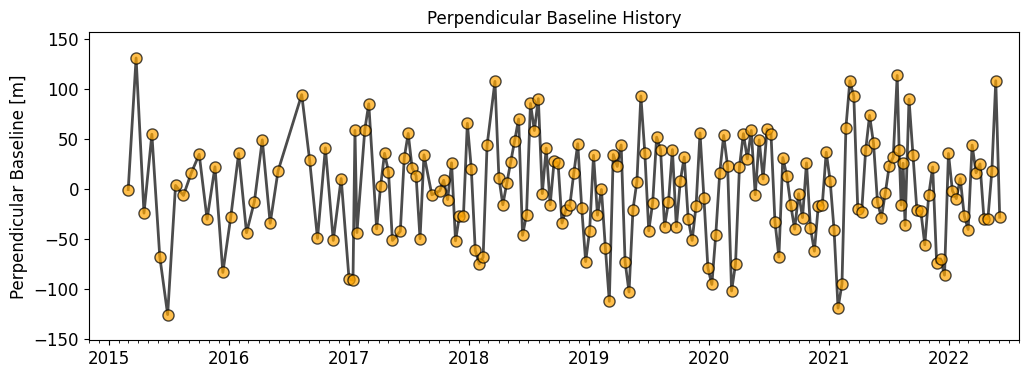

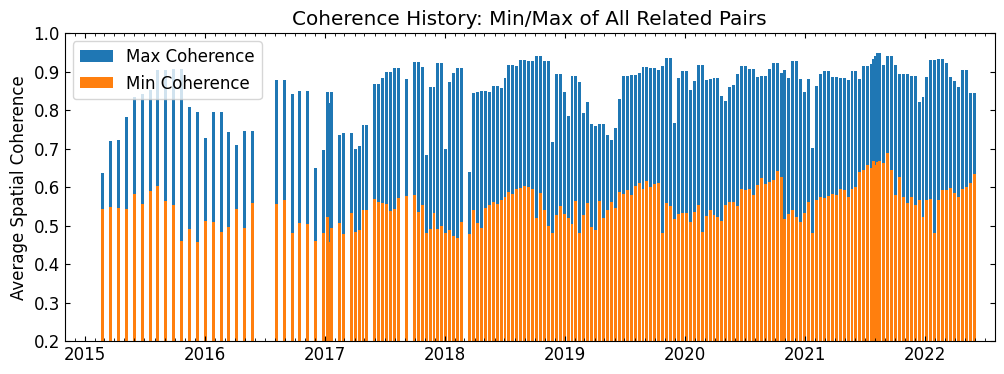

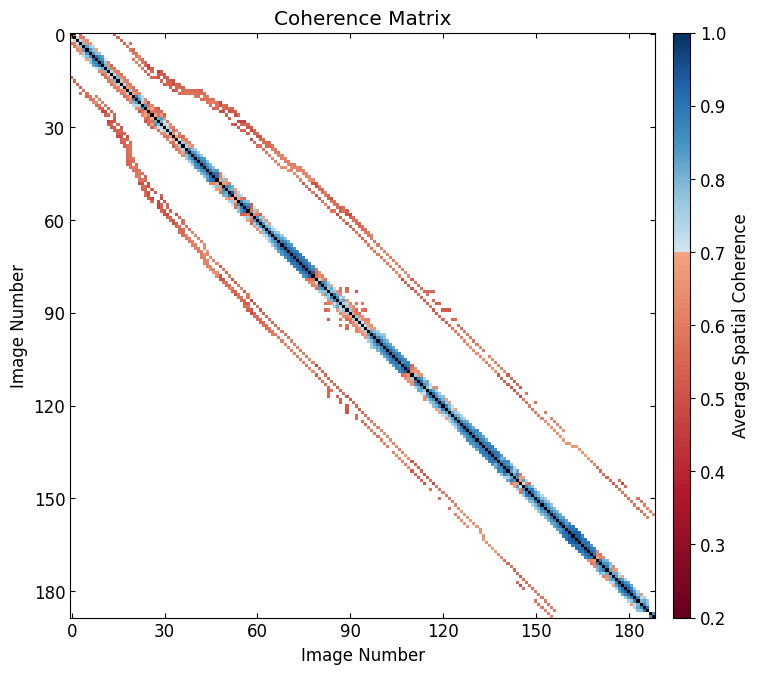

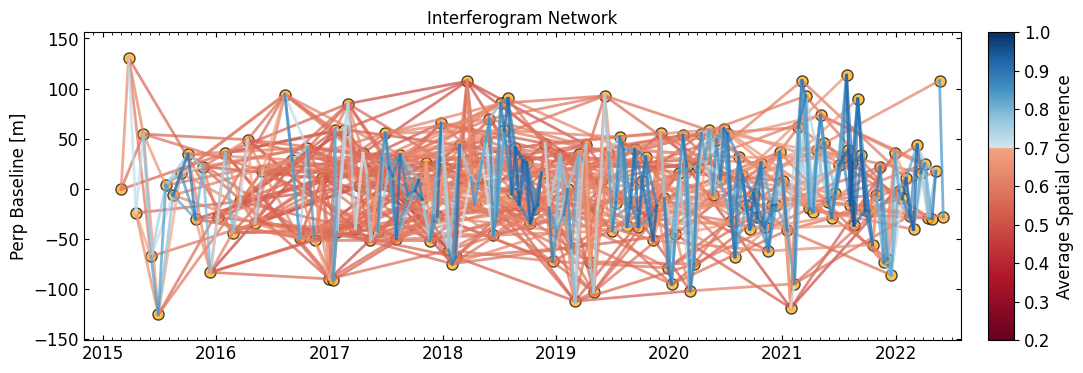

In [ ]:
plot_network.main('inputs/ifgramStack.h5 -t smallbaselineApp.cfg --figsize 12 4'.split())

# Visualización coherencia temporal y ángulo de incidencia

view.py temporalCoherence.h5 --noverbose


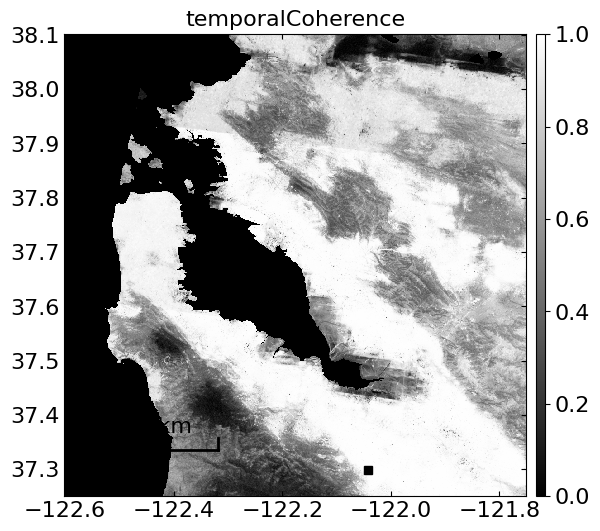

view.py maskTempCoh.h5 -c gray --noverbose


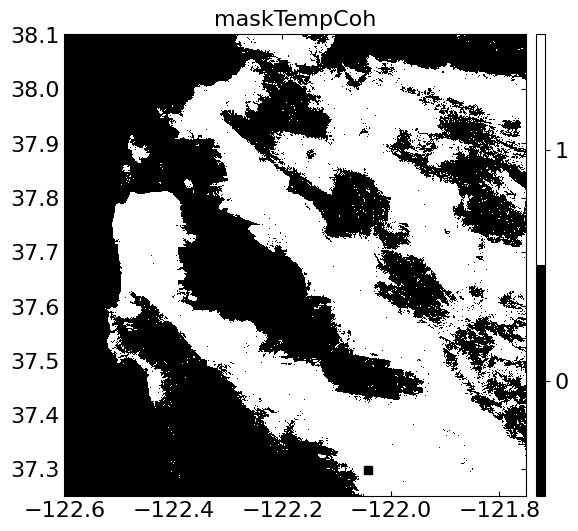

view.py inputs/geometryGeo.h5 height --noverbose


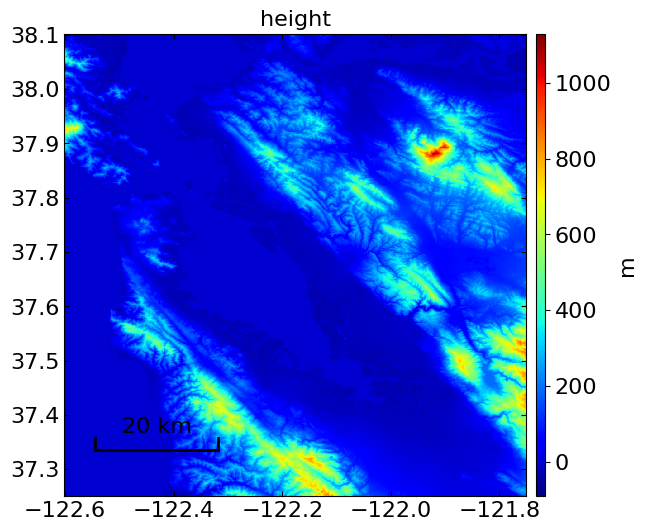

view.py inputs/geometryGeo.h5 incidenceAngle --noverbose


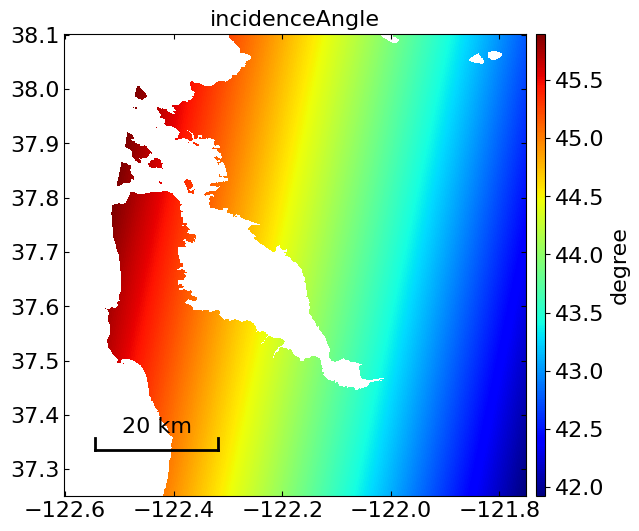

In [ ]:
# coherencia temporal
view.main('temporalCoherence.h5 --noverbose'.split())

# máscara de píxeles confiables
view.main('maskTempCoh.h5 -c gray --noverbose'.split())

# Angulo de incidencia
view.main('inputs/geometryGeo.h5 height --noverbose'.split())
view.main('inputs/geometryGeo.h5 incidenceAngle --noverbose'.split())

# Velocidad
view.main('velocity.h5 velocity -u mm -v -1 1 --noverbose'.split())

# Visualización de dos series temporales

view.py timeseries.h5 timeseries-20150301 -o timeseries_1.png --noverbose
Figure(750x600)
view.py timeseries.h5 timeseries-20150325 -o timeseries_2.png --noverbose
Figure(750x600)


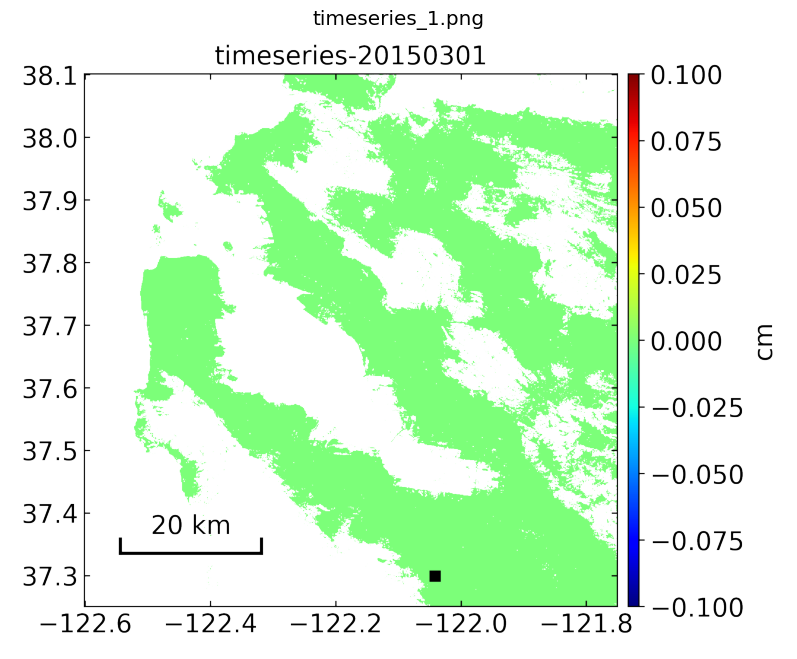

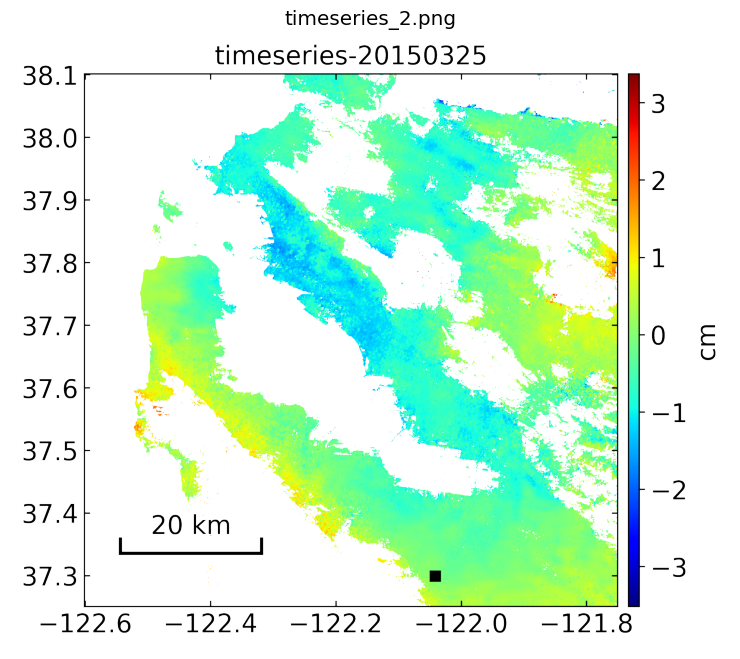

In [ ]:
!view.py timeseries.h5 timeseries-20150301 -o timeseries_1.png --noverbose
!view.py timeseries.h5 timeseries-20150325 -o timeseries_2.png --noverbose

for f in ['timeseries_1.png','timeseries_2.png']:
    img = Image.open(f)
    plt.figure(figsize=(15,8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f)
    plt.show()